# Entrenamiento CNN con Tensores Multiespectrales (Frijol)

Este notebook entrena una CNN para clasificar tratamientos de frijol usando tensores multicanal `H x W x 10`.

## 0. Librerias y semilla

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

tf.keras.utils.set_random_seed(42)

## 1. Configuracion

In [ ]:
# Dataset multiespectral
base_dir = "extracted_tensors_frijol_split"
manifest_path = "datasets/object_split_frijol_tensors.csv"

# Parametros de entrada
IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_CHANNELS = 10
BATCH_SIZE = 32

# Entrenamiento
EPOCHS = 100
LEARNING_RATE = 3e-4

# Normalizacion: zscore_masked -> z-score solo sobre pixeles de hoja (~21% del tensor)
# El fondo (zeros, ~79% de pixeles) no altera media ni std del calculo
NORMALIZATION_MODE = "zscore_masked"

# Regularizacion
L2_LAMBDA = 5e-5
DROPOUT_BLOCK1 = 0.10
DROPOUT_BLOCK2 = 0.20
DROPOUT_BLOCK3 = 0.25
DROPOUT_DENSE = 0.30

print("Configuracion:")
print(f"- EPOCHS={EPOCHS}, LR={LEARNING_RATE}, BATCH_SIZE={BATCH_SIZE}")
print(f"- NORMALIZATION_MODE={NORMALIZATION_MODE}")
print(f"- L2_LAMBDA={L2_LAMBDA}")
print(f"- DROPOUTS=({DROPOUT_BLOCK1}, {DROPOUT_BLOCK2}, {DROPOUT_BLOCK3}, {DROPOUT_DENSE})")


Configuracion:
- EPOCHS=100, LR=0.0003, BATCH_SIZE=32
- NORMALIZATION_MODE=zscore_masked
- L2_LAMBDA=5e-05
- DROPOUTS=(0.1, 0.2, 0.25, 0.3)


## 2. Carga de manifest y validacion inicial

In [3]:
if not os.path.isfile(manifest_path):
    raise FileNotFoundError(f"No existe manifest: {manifest_path}")

manifest_df = pd.read_csv(manifest_path)
required_cols = {"object_id", "split", "tensor_path", "tratamiento", "plant_id"}
missing_cols = required_cols - set(manifest_df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas en manifest: {sorted(missing_cols)}")

manifest_df = manifest_df.copy()
manifest_df["tensor_path"] = manifest_df["tensor_path"].astype(str)
manifest_df["object_id"] = manifest_df["object_id"].astype(str)
manifest_df["plant_id"] = manifest_df["plant_id"].astype(str)
manifest_df["tratamiento"] = manifest_df["tratamiento"].astype(int)
manifest_df["class_name"] = manifest_df["tratamiento"].map(lambda t: f"T{t}")

# Verificar existencia de archivos de tensor
manifest_df["exists"] = manifest_df["tensor_path"].map(os.path.isfile)
n_missing_files = int((~manifest_df["exists"]).sum())
if n_missing_files > 0:
    display(manifest_df.loc[~manifest_df["exists"], ["object_id", "tensor_path"]].head(10))
    raise ValueError(f"Hay {n_missing_files} rutas de tensor no existentes.")

print("Registros en manifest:", len(manifest_df))
print("Conteo por split:")
print(manifest_df["split"].value_counts().to_string())
print("Clases detectadas:", sorted(manifest_df["class_name"].unique().tolist()))
manifest_df.head()

Registros en manifest: 383
Conteo por split:
split
train    267
test      60
val       56
Clases detectadas: ['T1', 'T2', 'T3', 'T4']


,cultivo,fecha,plant_id,tratamiento,object_id,split,tensor_path,preview_path,height,width,channels,dtype,nonzero_voxels,source_ref_file,source_class_file,class_name,exists
0,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_001,val,extracted_tensors_frijol_split_v1\val\T2\REF__...,NaN,128,128,10,float32,36200,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat,T2,True
1,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_002,test,extracted_tensors_frijol_split_v1\test\T2\REF_...,NaN,128,128,10,float32,38680,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat,T2,True
2,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_003,train,extracted_tensors_frijol_split_v1\train\T2\REF...,NaN,128,128,10,float32,32180,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat,T2,True
3,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_004,train,extracted_tensors_frijol_split_v1\train\T2\REF...,NaN,128,128,10,float32,34870,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat,T2,True
4,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_005,train,extracted_tensors_frijol_split_v1\train\T2\REF...,NaN,128,128,10,float32,34420,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat,T2,True


## 3. Construccion de pool train+val y test final

In [ ]:
# Usar los splits definidos en el manifest
train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df   = manifest_df[manifest_df["split"] == "val"].copy()
test_df  = manifest_df[manifest_df["split"] == "test"].copy()

for df in [train_df, val_df, test_df]:
    if df.empty:
        raise ValueError(f"Split '{df['split'].iloc[0]}' vacio.")

class_names = sorted(train_df["class_name"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}

for df in [train_df, val_df, test_df]:
    df["label"] = df["class_name"].map(class_to_idx).astype(int)

train_paths  = train_df["tensor_path"].values
train_labels = train_df["label"].values
val_paths    = val_df["tensor_path"].values
val_labels   = val_df["label"].values
test_paths   = test_df["tensor_path"].values
test_labels  = test_df["label"].values

print(f"Train: {len(train_paths):,} | Val: {len(val_paths):,} | Test: {len(test_paths):,}")
print("Clases:", class_names)
print("\nDistribucion por clase:")
for split_name, labels in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    counts = {class_names[i]: int((labels == i).sum()) for i in range(len(class_names))}
    print(f"  {split_name}: {counts}")


Train: 267 | Val: 56 | Test: 60
Clases: ['T1', 'T2', 'T3', 'T4']

Distribucion por clase:
  train: {'T1': 67, 'T2': 67, 'T3': 67, 'T4': 66}
  val: {'T1': 14, 'T2': 14, 'T3': 14, 'T4': 14}
  test: {'T1': 15, 'T2': 15, 'T3': 15, 'T4': 15}


## 4. Validación de dataset

In [ ]:

train_objects = set(train_df["object_id"].unique())
val_objects   = set(val_df["object_id"].unique())
test_objects  = set(test_df["object_id"].unique())

overlap_train_test = train_objects & test_objects
overlap_val_test   = val_objects   & test_objects
overlap_train_val  = train_objects & val_objects

if overlap_train_test:
    raise ValueError(f"CRUCE train-test: {len(overlap_train_test)} objetos.")
if overlap_val_test:
    raise ValueError(f"CRUCE val-test: {len(overlap_val_test)} objetos.")

print(f"Cruce train-test:  {len(overlap_train_test)} (esperado: 0)")
print(f"Cruce val-test:    {len(overlap_val_test)} (esperado: 0)")
print(f"Cruce train-val:   {len(overlap_train_val)} (informativo)")

# Conteo de objetos (hojas) por imagen/plant_id y split
# Queremos index=plant_id y columns=split (train/val/test)
Leave_per_image_split = (
    manifest_df.groupby(["plant_id", "split"])
    .size()
    .unstack(fill_value=0)
)

# Asegurar columnas aunque algún split no exista
expected_splits = ["train", "val", "test"]
Leave_per_image_split = Leave_per_image_split.reindex(columns=expected_splits, fill_value=0)

print(f"   Imágenes totales: {manifest_df['plant_id'].nunique()}")

only_train = (Leave_per_image_split[["val", "test"]].sum(axis=1) == 0) & (Leave_per_image_split["train"] > 0)
print(f"   Imágenes con hojas SOLO en train: {int(only_train.sum())}")

multi_split = (Leave_per_image_split.gt(0).sum(axis=1) > 1).sum()
print(f"   Imágenes con hojas en VARIOS splits (esperado): {int(multi_split)}")

Cruce train-test:  0 (esperado: 0)
Cruce val-test:    0 (esperado: 0)
Cruce train-val:   0 (informativo)
   Imágenes totales: 12
   Imágenes con hojas SOLO en train: 0
   Imágenes con hojas en VARIOS splits (esperado): 12


## 5. Pipeline tf.data para tensores .npy multicanal

In [ ]:

def _read_npy_tensor(path_bytes):
    path = path_bytes.decode("utf-8")
    arr = np.load(path).astype(np.float32)
    if arr.ndim != 3:
        raise ValueError(f"Tensor invalido en {path}. shape={arr.shape}")
    return arr


def load_and_preprocess_tensor(path, label):
    tensor = tf.numpy_function(_read_npy_tensor, [path], tf.float32)
    
    tensor.set_shape([IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS])

    tensor = tf.where(tf.math.is_finite(tensor), tensor, tf.zeros_like(tensor))

    mask   = tf.cast(tf.reduce_any(tensor != 0, axis=-1, keepdims=True), tf.float32)
    n_leaf = tf.maximum(tf.reduce_sum(mask), 1.0)
    mean   = tf.reduce_sum(tensor * mask, axis=[0, 1], keepdims=True) / n_leaf
    diff   = (tensor - mean) * mask
    var    = tf.reduce_sum(tf.square(diff), axis=[0, 1], keepdims=True) / n_leaf
    std    = tf.sqrt(var + 1e-6)
    tensor = diff / std

    return tensor, tf.cast(label, tf.int32)


def make_dataset(paths, labels, batch_size=BATCH_SIZE, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=123, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess_tensor, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)


In [7]:
# Verificacion rapida de dimensiones
for x_batch, y_batch in train_ds.take(1):
    print("Batch X shape:", x_batch.shape)
    print("Batch y shape:", y_batch.shape)
    print("Rango X: min=", float(tf.reduce_min(x_batch)), " max=", float(tf.reduce_max(x_batch)))

Batch X shape: (32, 128, 128, 10)
Batch y shape: (32,)
Rango X: min= -6.993366241455078  max= 4.313874244689941


In [8]:
def contar_por_clase(labels_array, class_names):
    counts = pd.Series(labels_array).value_counts().sort_index()
    out = []
    for idx, cname in enumerate(class_names):
        out.append(int(counts.get(idx, 0)))
    return pd.Series(out, index=class_names)

print("Distribucion train interno:")
print(contar_por_clase(train_labels, class_names).to_string())
print("\nDistribucion val interna:")
print(contar_por_clase(val_labels, class_names).to_string())
print("\nDistribucion test final:")
print(contar_por_clase(test_labels, class_names).to_string())

Distribucion train interno:
T1    67
T2    67
T3    67
T4    66

Distribucion val interna:
T1    14
T2    14
T3    14
T4    14

Distribucion test final:
T1    15
T2    15
T3    15
T4    15


## 6. Visualizacion exploratoria

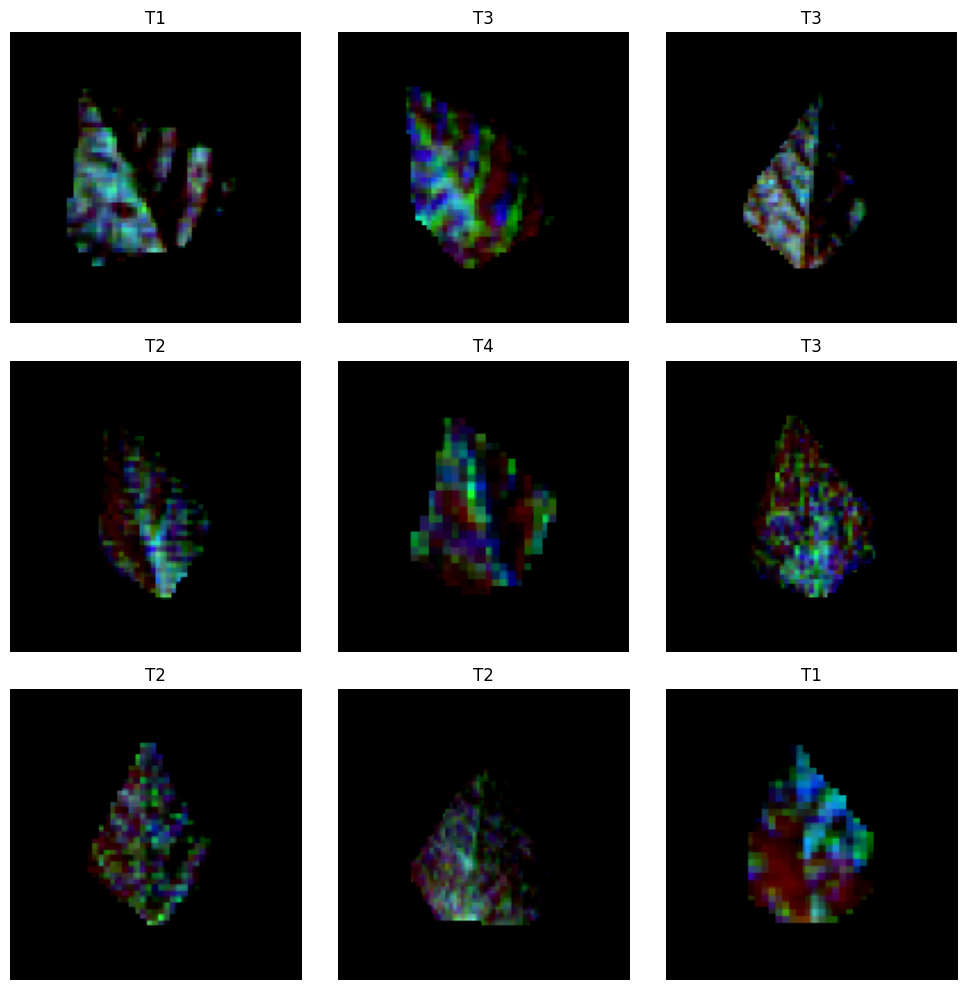

In [9]:
def tensor_to_rgb_preview(tensor, bands=(8, 4, 1)):
    b0, b1, b2 = bands
    rgb = np.stack([tensor[:, :, b0], tensor[:, :, b1], tensor[:, :, b2]], axis=-1)
    maxv = float(np.max(rgb))
    if maxv > 0:
        rgb = rgb / maxv
    return np.clip(rgb, 0.0, 1.0)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    images_np = images.numpy()
    labels_np = labels.numpy()
    n_show = min(9, images_np.shape[0])
    for i in range(n_show):
        ax = plt.subplot(3, 3, i + 1)
        rgb = tensor_to_rgb_preview(images_np[i], bands=(8, 4, 1))
        plt.imshow(rgb)
        plt.title(class_names[int(labels_np[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Modelo CNN multicanal

In [ ]:
num_classes = len(class_names)
reg = tf.keras.regularizers.l2(L2_LAMBDA)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
], name="data_augmentation")


inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, NUM_CHANNELS))

x = data_augmentation(inputs)

# Mezcla espectral: aprende que combinaciones de las 10 bandas son discriminativas
x = layers.Conv2D(NUM_CHANNELS * 2, 1, padding="same", activation="elu",
                  kernel_initializer="he_normal",
                  kernel_regularizer=reg, name="spectral_mixing")(x)

# Bloque 1: 128x128 -> 64x64
x = layers.SeparableConv2D(32, 3, padding="same", activation="elu",
                           depthwise_initializer="he_normal",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK1)(x)

# Bloque 2: 64x64 -> 32x32
x = layers.SeparableConv2D(64, 3, padding="same", activation="elu",
                           depthwise_initializer="he_normal",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK2)(x)

# Bloque 3: 32x32 -> 16x16
x = layers.SeparableConv2D(128, 3, padding="same", activation="elu",
                           depthwise_initializer="he_normal",
                            depthwise_regularizer=reg, pointwise_regularizer=reg)(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(DROPOUT_BLOCK3)(x)

# Agregacion global
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="elu", 
                 kernel_initializer="he_normal",
                 kernel_regularizer=reg)(x)
x = layers.Dropout(DROPOUT_DENSE)(x)
outputs = layers.Dense(num_classes)(x)

model = tf.keras.Model(inputs, outputs, name="frijol_spectral_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model.summary()


Model: "frijol_spectral_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_mixing (Conv2D)        │ (None, 128, 128, 20)   │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 32)   │           852 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,884 (81.58 KB)

 Trainable params: 20,884 (81.58 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento

In [ ]:
suffix = f"spectral_cnn_{NORMALIZATION_MODE}"
best_model_path = f"models/frijol/frijol_model_cnn_multispectral_tensor_{suffix}.keras"
history_csv     = f"results/training_history_frijol_cnn_multispectral_tensor_{suffix}.csv"
os.makedirs(os.path.dirname(best_model_path), exist_ok=True)
os.makedirs(os.path.dirname(history_csv), exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        mode="min",
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=7,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(history_csv, append=False),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

print(f"\nCheckpoint guardado en: {best_model_path}")
print(f"Historial en: {history_csv}")


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.2302 - loss: 1.4032
Epoch 1: val_accuracy improved from None to 0.25000, saving model to models/frijol/frijol_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras

Epoch 1: finished saving model to models/frijol/frijol_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - accuracy: 0.2210 - loss: 1.4039 - val_accuracy: 0.2500 - val_loss: 1.4023 - learning_rate: 3.0000e-04
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2017 - loss: 1.4044
Epoch 2: val_accuracy did not improve from 0.25000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.2210 - loss: 1.4029 - val_accuracy: 0.2500 - val_loss: 1.4020 - learning_rate: 3.0000e-04
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.2377 - loss: 1.4021
Epoch 3: val_accuracy did not improve from 0.25000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - accuracy: 0.2322 - loss: 1.4018 - val_accu

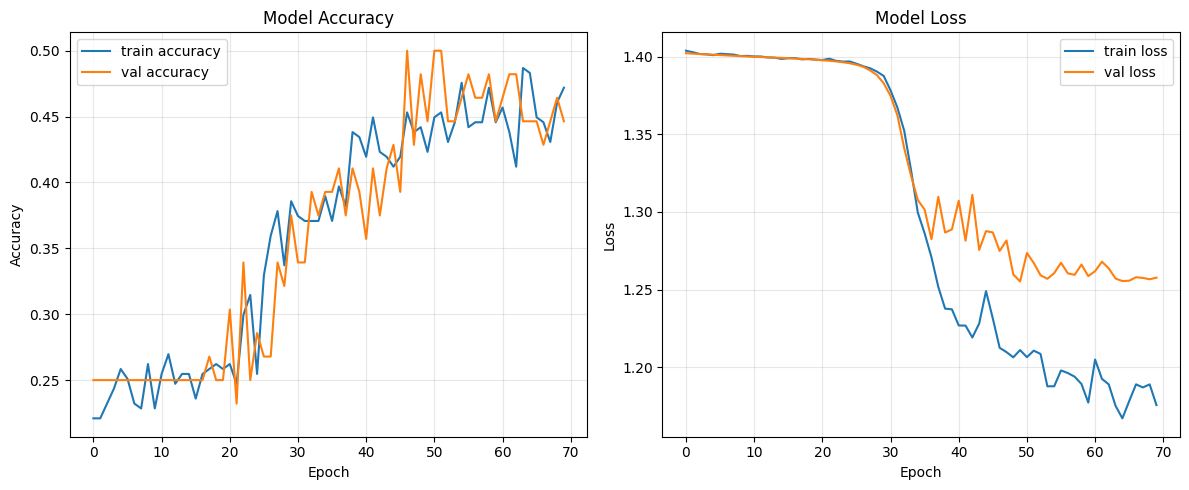

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Evaluacion

In [15]:

# El modelo en memoria ya tiene los mejores pesos restaurados por EarlyStopping
# (restore_best_weights=True). Solo cargar checkpoint si se ejecuta esta celda
# en una sesion distinta a la del entrenamiento.
trained_model = model

print(f"Modelo listo para evaluacion (best val_accuracy restaurado por EarlyStopping).")
print(f"Checkpoint disponible en: {best_model_path}")


Modelo listo para evaluacion (best val_accuracy restaurado por EarlyStopping).
Checkpoint disponible en: models/frijol/frijol_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras


In [16]:
def collect_predictions(ds, model):
    y_true, y_pred = [], []
    for x_batch, y_batch in ds:
        logits = model.predict(x_batch, verbose=0)
        preds = np.argmax(logits, axis=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

print("Prediciendo train interno...")
y_train_true, y_train_pred = collect_predictions(train_ds, trained_model)

print("Prediciendo test final...")
y_test_true, y_test_pred = collect_predictions(test_ds, trained_model)

Prediciendo train interno...
Prediciendo test final...


In [17]:
# Diagnostico de colapso por clase
def resumen_predicciones(y_true, y_pred, class_names, titulo):
    print(f"\n=== {titulo} ===")
    true_counts = np.bincount(y_true, minlength=len(class_names))
    pred_counts = np.bincount(y_pred, minlength=len(class_names))
    df = pd.DataFrame({
        "clase": class_names,
        "true": true_counts,
        "pred": pred_counts,
    })
    df["pred_pct"] = (df["pred"] / max(1, df["pred"].sum()) * 100).round(2)
    print(df.to_string(index=False))

y_val_true, y_val_pred = collect_predictions(val_ds, trained_model)
resumen_predicciones(y_train_true, y_train_pred, class_names, "Train interno")
resumen_predicciones(y_val_true, y_val_pred, class_names, "Val interna")
resumen_predicciones(y_test_true, y_test_pred, class_names, "Test final")


=== Train interno ===
clase  true  pred  pred_pct
   T1    67    95     35.58
   T2    67    53     19.85
   T3    67    37     13.86
   T4    66    82     30.71

=== Val interna ===
clase  true  pred  pred_pct
   T1    14    18     32.14
   T2    14     9     16.07
   T3    14    13     23.21
   T4    14    16     28.57

=== Test final ===
clase  true  pred  pred_pct
   T1    15    22     36.67
   T2    15     6     10.00
   T3    15    10     16.67
   T4    15    22     36.67


In [18]:
# Metricas train
train_accuracy = accuracy_score(y_train_true, y_train_pred)
train_precision = precision_score(y_train_true, y_train_pred, average="macro")
train_f1 = f1_score(y_train_true, y_train_pred, average="macro")
train_kappa = cohen_kappa_score(y_train_true, y_train_pred)

# Metricas test
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_precision = precision_score(y_test_true, y_test_pred, average="macro")
test_f1 = f1_score(y_test_true, y_test_pred, average="macro")
test_kappa = cohen_kappa_score(y_test_true, y_test_pred)

print("-" * 70)
print(f"{'Metrica':<22} | {'Train interno':<20} | {'Test final':<20}")
print("-" * 70)
print(f"{'Accuracy':<22} | {train_accuracy:<20.4f} | {test_accuracy:<20.4f}")
print(f"{'Precision':<22} | {train_precision:<20.4f} | {test_precision:<20.4f}")
print(f"{'F1-Score':<22} | {train_f1:<20.4f} | {test_f1:<20.4f}")
print(f"{'Kappa Score':<22} | {train_kappa:<20.4f} | {test_kappa:<20.4f}")
print("-" * 70)

----------------------------------------------------------------------
Metrica                | Train interno        | Test final          
----------------------------------------------------------------------
Accuracy               | 0.4607               | 0.4333              
Precision              | 0.4374               | 0.3697              
F1-Score               | 0.4357               | 0.3784              
Kappa Score            | 0.2811               | 0.2444              
----------------------------------------------------------------------


In [19]:
print("Reporte de clasificacion (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names, zero_division=0))

print("\nReporte de clasificacion (Train interno):")
print(classification_report(y_train_true, y_train_pred, target_names=class_names, zero_division=0))

print("\nReporte de clasificacion (Val interna):")
print(classification_report(y_val_true, y_val_pred, target_names=class_names, zero_division=0))

Reporte de clasificacion (Test):
              precision    recall  f1-score   support

          T1       0.64      0.93      0.76        15
          T2       0.33      0.13      0.19        15
          T3       0.10      0.07      0.08        15
          T4       0.41      0.60      0.49        15

    accuracy                           0.43        60
   macro avg       0.37      0.43      0.38        60
weighted avg       0.37      0.43      0.38        60


Reporte de clasificacion (Train interno):
              precision    recall  f1-score   support

          T1       0.57      0.81      0.67        67
          T2       0.42      0.33      0.37        67
          T3       0.35      0.19      0.25        67
          T4       0.41      0.52      0.46        66

    accuracy                           0.46       267
   macro avg       0.44      0.46      0.44       267
weighted avg       0.44      0.46      0.44       267


Reporte de clasificacion (Val interna):
             

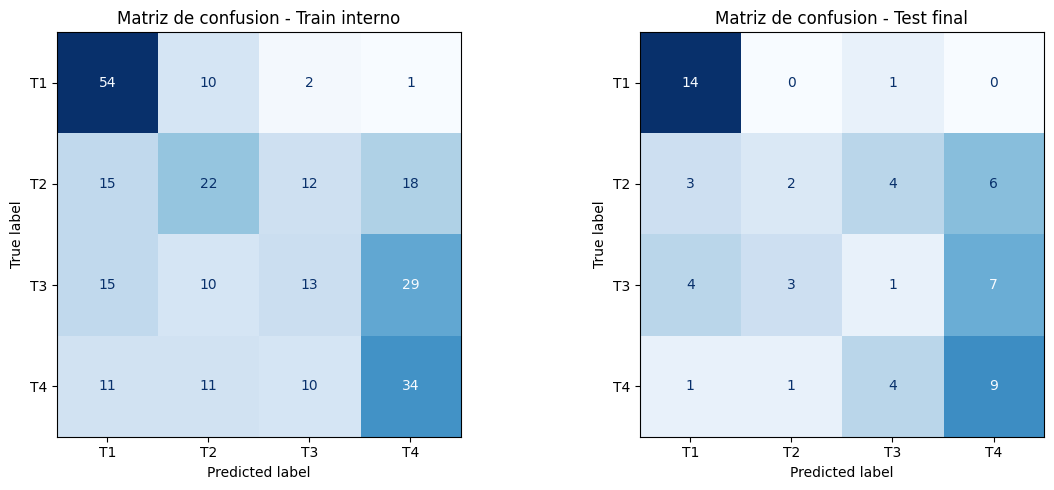

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train_true, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusion - Train interno")
axes[0].grid(False)

cm_test = confusion_matrix(y_test_true, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Matriz de confusion - Test final")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 10. Visualizacion de zonas de activacion

Grad-CAM calcula los gradientes de la clase predicha respecto a los mapas de activacion de la ultima capa convolucional (`SeparableConv2D`). Zonas con gradientes altos → el modelo considera esa region espacial determinante para la clasificacion.

**Interpretacion biologica esperada:**
- Si la CNN aprendio síntomas de deficiencia de P (bordes de hoja, nervaduras), los mapas de calor deben concentrarse en esas zonas.
- Activaciones difusas en el limbo central sugieren que el modelo usa textura espectral global en lugar de patrones localizados.


In [21]:

def _get_last_conv_layer_name(model):
    """Retorna el nombre de la ultima SeparableConv2D o Conv2D del modelo."""
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.SeparableConv2D, tf.keras.layers.Conv2D)):
            return layer.name
    raise ValueError("No se encontro capa convolucional en el modelo.")


def gradcam_heatmap(img_array, model, conv_layer_name, class_index=None):
    """
    Calcula el mapa de calor Grad-CAM para una muestra.

    img_array   : np.ndarray o tf.Tensor de shape (1, H, W, C), ya normalizado.
    class_index : indice de clase objetivo; si None, usa la prediccion del modelo.
    Retorna     : (heatmap np.ndarray shape (h_conv, w_conv) en [0,1], class_index usado)
    """
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(conv_layer_name).output, model.output],
    )
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor, training=False)
        if class_index is None:
            class_index = int(tf.argmax(preds[0]))
        score = preds[:, class_index]

    grads = tape.gradient(score, conv_out)              # (1, h, w, filters)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))      # (filters,)
    cam = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis])  # (h, w)
    cam = tf.nn.relu(cam).numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, class_index


def overlay_heatmap(img_rgb, heatmap, alpha=0.50):
    """
    Superpone heatmap (h_conv, w_conv) sobre img_rgb (H, W, 3).
    Usa resize bilineal de TensorFlow para evitar dependencia de OpenCV.
    """
    H, W = img_rgb.shape[:2]
    cam_resized = tf.image.resize(
        heatmap[..., np.newaxis], [H, W], method="bilinear"
    ).numpy().squeeze()
    colored = plt.cm.jet(cam_resized)[:, :, :3]  # colormap jet, drop alpha
    return np.clip((1 - alpha) * img_rgb + alpha * colored, 0, 1), cam_resized


last_conv_layer = _get_last_conv_layer_name(trained_model)
print(f"Capa objetivo Grad-CAM: '{last_conv_layer}'")

# En Keras 3 algunos layers ya no exponen .output_shape; usar layer.output.shape es más robusto
target_layer = trained_model.get_layer(last_conv_layer)
activation_shape = getattr(target_layer, "output_shape", None)
if activation_shape is None:
    activation_shape = tuple(target_layer.output.shape)
print(f"Shape de activaciones: {activation_shape}")

Capa objetivo Grad-CAM: 'separable_conv2d_2'
Shape de activaciones: (None, 32, 32, 128)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_14364\3667831549.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 1])


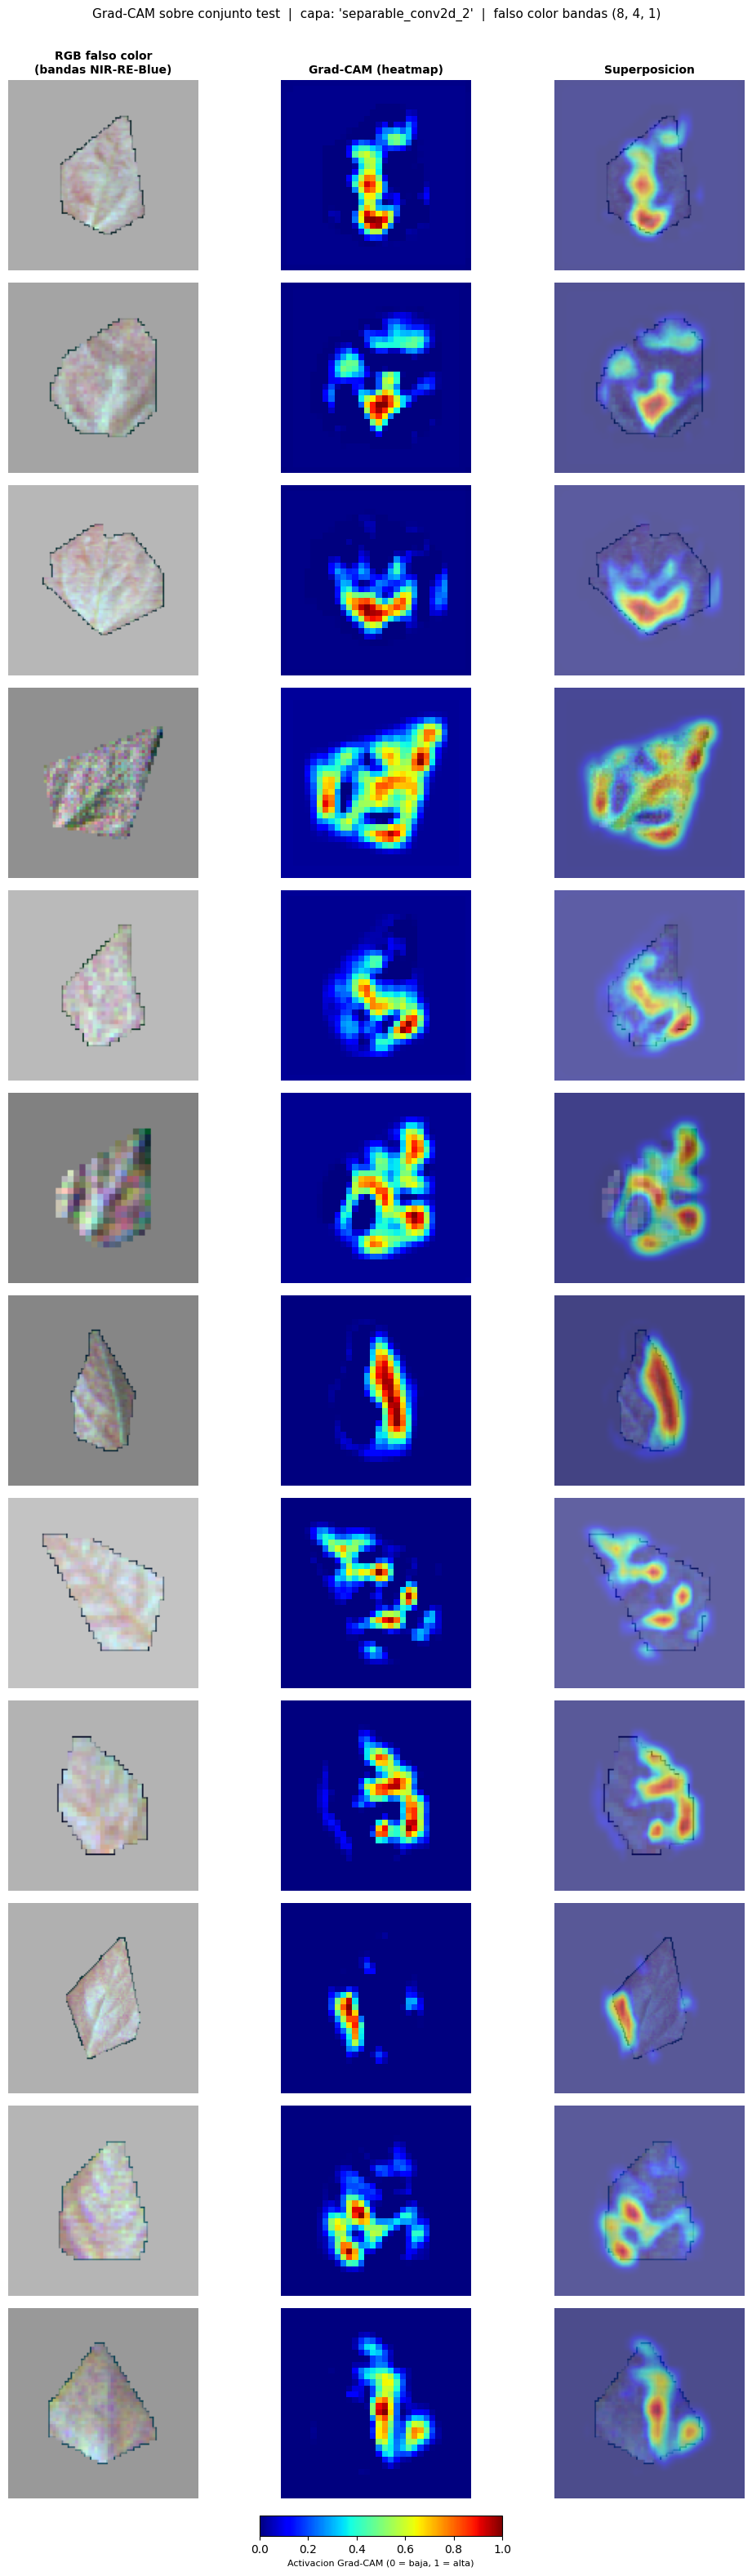

In [ ]:
# Parametros de visualizacion
N_PER_CLASS   = 3     # muestras de test por clase
ALPHA_OVERLAY = 0.50  # peso del heatmap en la superposicion
BANDS_RGB     = (8, 4, 1)  # bandas para falso color (NIR, Red-Edge, Blue)

# ── Recolectar hasta N_PER_CLASS tensores de test por clase ────────────────
samples_by_class = {i: [] for i in range(len(class_names))}
for xb, yb in test_ds:
    for xi, yi in zip(xb.numpy(), yb.numpy()):
        lbl = int(yi)
        if len(samples_by_class[lbl]) < N_PER_CLASS:
            samples_by_class[lbl].append(xi)
    if all(len(v) >= N_PER_CLASS for v in samples_by_class.values()):
        break

# ── Grid: [clase x muestra] filas, 3 columnas (RGB | Heatmap | Superposicion) ──
total_rows = len(class_names) * N_PER_CLASS
fig, axes = plt.subplots(total_rows, 3, figsize=(11, 2.6 * total_rows))

col_titles = ["RGB falso color\n(bandas NIR-RE-Blue)", "Grad-CAM (heatmap)", "Superposicion"]
for col, ct in enumerate(col_titles):
    axes[0, col].set_title(ct, fontsize=10, fontweight="bold")

row = 0
for cls_idx, cls_name in enumerate(class_names):
    for sample_i, tensor in enumerate(samples_by_class[cls_idx][:N_PER_CLASS]):
        img_input = tensor[np.newaxis]  # (1, H, W, C)

        # Grad-CAM usando la clase verdadera (para evaluar atencion en clase correcta)
        cam, pred_idx = gradcam_heatmap(img_input, trained_model, last_conv_layer,
                                        class_index=cls_idx)

        # Prediccion real (sin forzar clase) para mostrar si es correcta
        _, pred_auto = gradcam_heatmap(img_input, trained_model, last_conv_layer)
        is_correct = pred_auto == cls_idx
        result_str = "✓" if is_correct else f"✗ → {class_names[pred_auto]}"

        # Falso color RGB con las 3 bandas seleccionadas
        b0, b1, b2 = BANDS_RGB
        rgb = np.stack([tensor[:, :, b0], tensor[:, :, b1], tensor[:, :, b2]], axis=-1)
        rmin, rmax = rgb.min(), rgb.max()
        rgb_norm = np.clip((rgb - rmin) / (rmax - rmin + 1e-6), 0, 1)

        overlay, _ = overlay_heatmap(rgb_norm, cam, alpha=ALPHA_OVERLAY)

        axes[row, 0].imshow(rgb_norm)
        axes[row, 0].set_ylabel(f"{cls_name}  #{sample_i + 1}\n({result_str})",
                                fontsize=8, labelpad=4)
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(cam, cmap="jet", vmin=0, vmax=1)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].axis("off")

        row += 1

# Barra de color global para el heatmap
cbar_ax = fig.add_axes([0.37, 0.01, 0.27, 0.008])
plt.colorbar(im, cax=cbar_ax, orientation="horizontal").set_label(
    "Activacion Grad-CAM (0 = baja, 1 = alta)", fontsize=8
)

plt.suptitle(
    f"Grad-CAM sobre conjunto test  |  capa: '{last_conv_layer}'  |  "
    f"falso color bandas {BANDS_RGB}",
    fontsize=11, y=1.002,
)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()


## 11. Guardado de artefactos


In [ ]:
# Guardar modelo final
final_model_path = "models/frijol/frijol_model_cnn_multispectral_tensor_final.keras"
trained_model.save(final_model_path)
print(f"Modelo final guardado en: {final_model_path}")
print(f"Mejor checkpoint: {best_model_path}")
print(f"Historial: {history_csv}")

Modelo final guardado en: models/frijol/frijol_model_cnn_multispectral_tensor_final.keras
Mejor checkpoint: models/frijol/frijol_model_cnn_multispectral_tensor_spectral_cnn_zscore_masked.keras
Historial: results/training_history_frijol_cnn_multispectral_tensor_spectral_cnn_zscore_masked.csv
